In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              f1_score, precision_score, recall_score, accuracy_score,
                              average_precision_score)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries loaded!")
print(f"XGBoost ready to train.")

✅ Libraries loaded!
XGBoost ready to train.


In [2]:
# We use the ORIGINAL (non-SMOTE) training data here, because XGBoost has
# a built-in way to handle imbalance: scale_pos_weight. This often works
# even better than SMOTE for XGBoost.

X_train = joblib.load('../data/processed/X_train_original.pkl')
y_train = joblib.load('../data/processed/y_train_original.pkl')
X_test  = joblib.load('../data/processed/X_test.pkl')
y_test  = joblib.load('../data/processed/y_test.pkl')

# Calculate class imbalance ratio for scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Negative : Positive ratio = {neg_count:,} : {pos_count}")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

X_train: (227845, 30)
X_test:  (56962, 30)
Negative : Positive ratio = 227,451 : 394
scale_pos_weight = 577.29


In [3]:
print("🚀 Training XGBoost... (should take 1-3 minutes)")
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=300,           # number of boosting rounds
    max_depth=6,                # depth of each tree
    learning_rate=0.1,          # how much each tree contributes
    subsample=0.8,              # use 80% of rows per tree (prevents overfit)
    colsample_bytree=0.8,       # use 80% of features per tree
    scale_pos_weight=scale_pos_weight,   # tell XGBoost fraud is rare
    random_state=42,
    n_jobs=-1,                  # use all CPU cores
    eval_metric='aucpr',        # optimize for precision-recall AUC
    tree_method='hist',         # fast histogram-based training
    verbosity=1,
)

xgb_model.fit(X_train, y_train, 
              eval_set=[(X_test, y_test)], 
              verbose=50)        # print metrics every 50 rounds

elapsed = time.time() - start
print(f"\n✅ Training done in {elapsed:.1f} seconds ({elapsed/60:.1f} min)")

🚀 Training XGBoost... (should take 1-3 minutes)
[0]	validation_0-aucpr:0.44904
[50]	validation_0-aucpr:0.82910
[100]	validation_0-aucpr:0.86875
[150]	validation_0-aucpr:0.87859
[200]	validation_0-aucpr:0.87992
[250]	validation_0-aucpr:0.88160
[299]	validation_0-aucpr:0.88167

✅ Training done in 7.4 seconds (0.1 min)


In [4]:
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)
pr_auc    = average_precision_score(y_test, y_proba)

print("=" * 60)
print("🏆 XGBOOST — TEST SET PERFORMANCE")
print("=" * 60)
print(f"  Accuracy:     {accuracy*100:.3f}%")
print(f"  Precision:    {precision*100:.2f}%")
print(f"  Recall:       {recall*100:.2f}%")
print(f"  F1-Score:     {f1:.4f}")
print(f"  ROC-AUC:      {roc_auc:.4f}")
print(f"  PR-AUC:       {pr_auc:.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

🏆 XGBOOST — TEST SET PERFORMANCE
  Accuracy:     99.953%
  Precision:    87.37%
  Recall:       84.69%
  F1-Score:     0.8601
  ROC-AUC:      0.9819
  PR-AUC:       0.8818

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.87      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



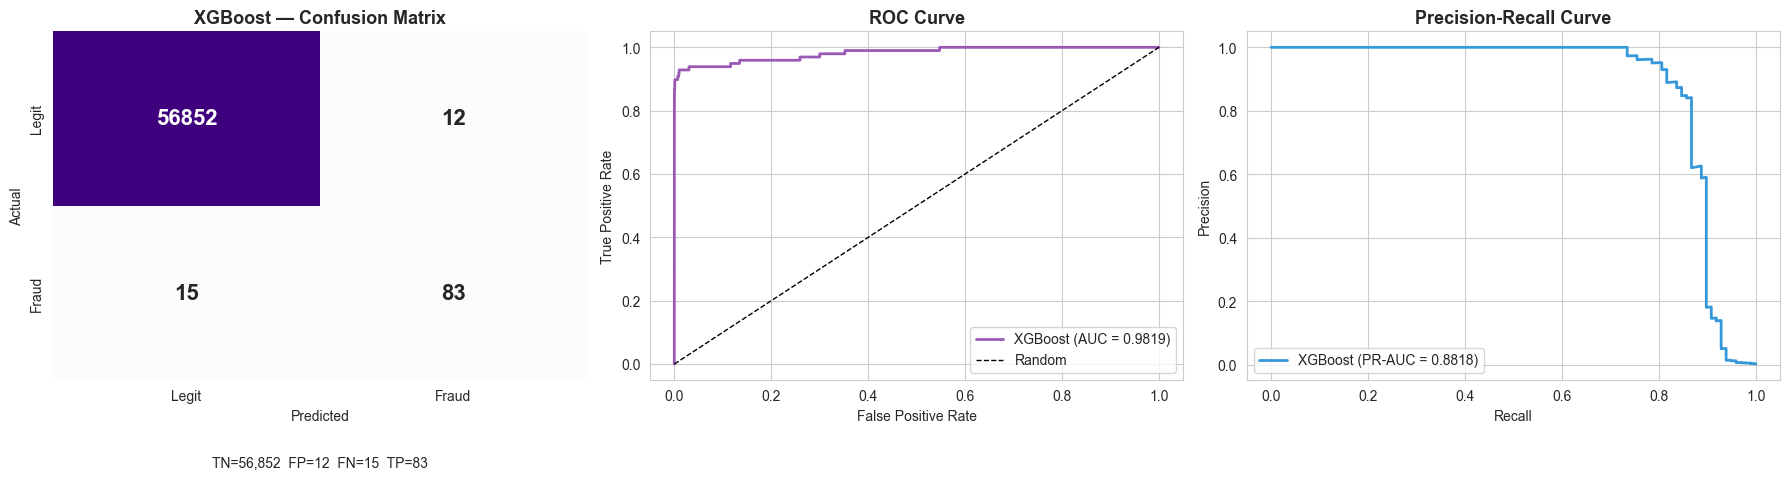

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'],
            cbar=False, annot_kws={"size": 16, "weight": "bold"})
axes[0].set_title('XGBoost — Confusion Matrix', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.25, f'TN={tn:,}  FP={fp}  FN={fn}  TP={tp}',
             ha='center', transform=axes[0].transAxes, fontsize=10)

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#9b59b6', linewidth=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(rec, prec, color='#3498db', linewidth=2, label=f'XGBoost (PR-AUC = {pr_auc:.4f})')
axes[2].set_title('Precision-Recall Curve', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')

plt.tight_layout()
plt.savefig('../reports/08_xgboost_performance.png', dpi=150, bbox_inches='tight')
plt.show()

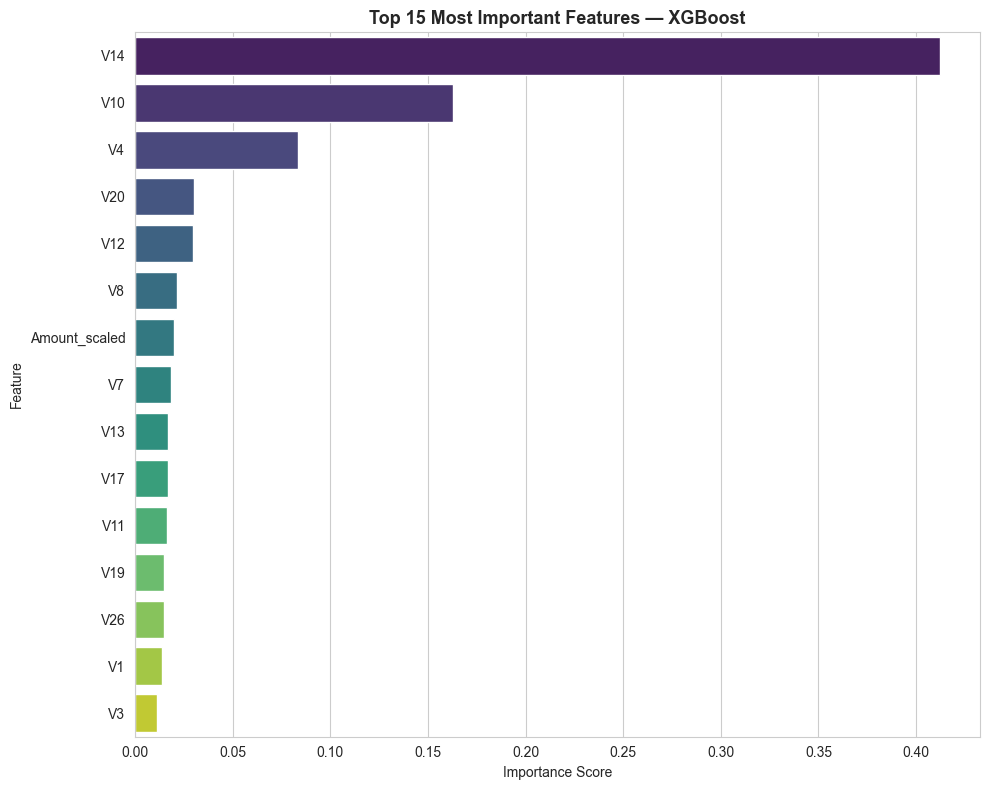

🎯 TOP 10 FEATURES:
      Feature  Importance
          V14    0.412108
          V10    0.162771
           V4    0.083523
          V20    0.030296
          V12    0.029665
           V8    0.021239
Amount_scaled    0.019968
           V7    0.018361
          V13    0.016881
          V17    0.016798


In [6]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features — XGBoost', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/09_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("🎯 TOP 10 FEATURES:")
print(importances.head(10).to_string(index=False))

In [7]:
joblib.dump(xgb_model, '../models/xgboost.pkl')

xgb_results = {
    'model_name': 'XGBoost',
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'roc_auc': roc_auc,
    'pr_auc': pr_auc,
    'training_time_sec': elapsed,
    'confusion_matrix': cm.tolist(),
}
joblib.dump(xgb_results, '../models/xgb_results.pkl')

print("💾 Model saved to: models/xgboost.pkl")
print("💾 Metrics saved to: models/xgb_results.pkl")

# Quick comparison to Random Forest
rf_results = joblib.load('../models/rf_results.pkl')
print("\n" + "=" * 60)
print("⚔️  RANDOM FOREST vs XGBOOST")
print("=" * 60)
print(f"{'Metric':<15}{'Random Forest':<18}{'XGBoost':<15}{'Winner'}")
print("-" * 60)
for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']:
    rf_val = rf_results[metric]
    xgb_val = xgb_results[metric]
    winner = '🏆 XGBoost' if xgb_val > rf_val else '🌲 RF' if rf_val > xgb_val else 'tie'
    print(f"{metric:<15}{rf_val:<18.4f}{xgb_val:<15.4f}{winner}")

print("\n✅ PHASE 6 COMPLETE!")
print("🚀 Next: Phase 7 — Neural Network (TensorFlow)")

💾 Model saved to: models/xgboost.pkl
💾 Metrics saved to: models/xgb_results.pkl

⚔️  RANDOM FOREST vs XGBOOST
Metric         Random Forest     XGBoost        Winner
------------------------------------------------------------
accuracy       0.9992            0.9995         🏆 XGBoost
precision      0.7387            0.8737         🏆 XGBoost
recall         0.8367            0.8469         🏆 XGBoost
f1_score       0.7847            0.8601         🏆 XGBoost
roc_auc        0.9516            0.9819         🏆 XGBoost
pr_auc         0.8577            0.8818         🏆 XGBoost

✅ PHASE 6 COMPLETE!
🚀 Next: Phase 7 — Neural Network (TensorFlow)
